# Fase 2: Ejecución del Análisis y Cierre del Loop Clínico
## Proyecto Integrador - Predicción de Severidad en Crisis Asmáticas Pediátricas
**Integrantes:** Juan Pablo Vivas (23105) | Javier Ochoa (23758) | Allan Lemus (23262)  
**Curso:** Análisis de Datos Biomédicos (BE3006) – Universidad del Valle de Guatemala  

---

### 1. Introducción y Justificación Clínica (Cierre del Loop)
En Guatemala, se estima que el 13% de la población pediátrica sufre de asma. Uno de los mayores retos en las salas de urgencias es la clasificación rápida y certera de los pacientes. En la Fase 1 se planteó inicialmente un modelo multiclase (Severidad: Leve, Moderada, Severa). Sin embargo, tras auditar los datos biomédicos, se identificó que las variables predictoras disponibles son de naturaleza puramente binaria (presencia/ausencia de síntomas), lo que limitaba la capacidad matemática de los algoritmos para diferenciar sutilmente tres niveles continuos.

**Modificación Metodológica Justificada:** Para optimizar el rendimiento del pipeline y responder de manera directa a la toma de decisiones clínicas prioritarias, transformamos el problema en un entorno de **Clasificación Binaria: Paciente Estable (Bueno) vs. Paciente Grave (Malo)**. En urgencias pediátricas, la prioridad crítica absoluta es evitar los Falsos Negativos (dar de alta erróneamente a un niño grave), por lo que se priorizará maximizar el **Recall (Sensibilidad)** y el **ROC-AUC**.

### 2. Objetivos del Dashboard
* Integrar nuevos síntomas clínicos clave (`Tiredness`, `Dry-Cough`, `Difficulty-in-Breathing`, `Sore-Throat`) para enriquecer la firma sintomática.
* Evaluar de forma transparente 6 aproximaciones algorítmicas (Regresión Logística, Naive Bayes, Random Forest Profundo, Redes Neuronales MLP, Gradient Boosting y XGBoost).
* Garantizar la reproducibilidad clínica mediante un pipeline hermético libre de *Data Leakage* (Fuga de Datos).

In [26]:
# =========================================================================
# 1. IMPORTS Y CONFIGURACIÓN GENERAL 
# =========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier  

# Nota: Si no tenés instalado xgboost en tu entorno, corre en una celda vacía: pip install xgboost
from xgboost import XGBClassifier 

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)

# Configuración visual para el dashboard
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 12})
print("[INFO] Librerías del ecosistema de Data Science cargadas exitosamente.")

[INFO] Librerías del ecosistema de Data Science cargadas exitosamente.


### 3. Carga de Datos e Ingeniería de Características Clínicas
En este paso, cargamos el archivo `processed-data.csv` y generamos una nueva métrica agregada llamada `Total_Symptoms`. Esta variable continua cuantifica la "carga sintomática" total acumulada por el paciente pediátrico, facilitando que algoritmos como la Regresión Logística y las Redes Neuronales mapeen el riesgo de forma cuantitativa.

In [18]:
# =========================================================
# 2. CARGA E INGENIERÍA DE VARIABLES
# =========================================================
df = pd.read_csv("processed-data.csv")

# Agregación de variables sintomáticas
posibles_sintomas = ['Tiredness', 'Dry-Cough', 'Difficulty-in-Breathing', 'Sore-Throat', 'Runny-Nose']
sintomas_presentes = [col for col in posibles_sintomas if col in df.columns]
df['Total_Symptoms'] = df[sintomas_presentes].sum(axis=1)

# Construcción del Target Binario (Grave vs Estable)
col_severity = [col for col in df.columns if 'severity' in col.lower()]
col_graves = [c for c in col_severity if 'severe' in c.lower() or 'moderate' in c.lower()]

if len(col_graves) > 0:
    df['Target_Grave'] = (df[col_graves].sum(axis=1) > 0).astype(int)
else:
    col_none = [c for c in col_severity if 'none' in c.lower() or 'mild' in c.lower()]
    df['Target_Grave'] = (df[col_none].sum(axis=1) == 0).astype(int)


print("DETALLE DE LAS PRIMERAS FILAS REGISTRADAS:")
# Muestra las primeras 5 filas de forma tabular 
display(df[['Total_Symptoms', 'Target_Grave'] + sintomas_presentes].head().style.set_properties(**{'background-color': '#f9f9f9', 'border-color': 'white'}))

# Crear dataframe de distribución para que se imprima como tabla 
dist_df = pd.DataFrame({
    'Condición Clínica': ['Estable (0)', 'Grave / Crítico (1)'],
    'Cantidad de Pacientes': df['Target_Grave'].value_counts().values,
    'Porcentaje del Total': [f"{x:.2f}%" for x in (df['Target_Grave'].value_counts(normalize=True) * 100).values]
})

print("\n PREVALENCIA EPIDEMIOLÓGICA EN EL DATASET:")
display(dist_df.style.hide(axis='index').set_properties(**{'text-align': 'center'}).background_gradient(cmap='Blues', subset=['Cantidad de Pacientes']))

DETALLE DE LAS PRIMERAS FILAS REGISTRADAS:


,Total_Symptoms,Target_Grave,Tiredness,Dry-Cough,Difficulty-in-Breathing,Sore-Throat,Runny-Nose
0,5,0,1,1,1,1,1
1,5,0,1,1,1,1,1
2,5,0,1,1,1,1,1
3,5,1,1,1,1,1,1
4,5,1,1,1,1,1,1



 PREVALENCIA EPIDEMIOLÓGICA EN EL DATASET:


Condición Clínica,Cantidad de Pacientes,Porcentaje del Total
Estable (0),237600,75.00%
Grave / Crítico (1),79200,25.00%


## 3.1 Análisis Exploratorio de Datos

Con el fin de cerrar el loop clínico y validar la coherencia biológica de nuestro dataset antes del modelado predictivo, se realizan dos análisis visuales estratégicos. El objetivo es comprobar si la carga sintomática acumulada se traduce matemáticamente en una mayor severidad y mapear qué variables biomédicas tienen mayor prevalencia en las crisis asmáticas graves.

* **Gráfico de Caja (Izquierda):** Evalúa la distribución del número total de síntomas simultáneos (`Total_Symptoms`) según el estado real del paciente (`Target_Grave`). Permite verificar la hipótesis de que a mayor acumulación de disfunciones respiratorias, mayor es la probabilidad de clasificar la crisis como de alta severidad.
* **Gráfico de Barras (Derecha):** Muestra la prevalencia porcentual exacta de cada síntoma dentro del subgrupo de pacientes críticos. Esto ayuda al cuerpo médico a identificar de manera rápida los factores de riesgo y "red flags" (banderas rojas) más frecuentes en la emergencia pediátrica.

C:\Users\franc\AppData\Local\Temp\ipykernel_37424\1465327438.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target_Grave', y='Total_Symptoms', data=df, palette='Set2')
C:\Users\franc\AppData\Local\Temp\ipykernel_37424\1465327438.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sintomas_frecuencia.values, y=sintomas_frecuencia.index, palette='Reds_r')


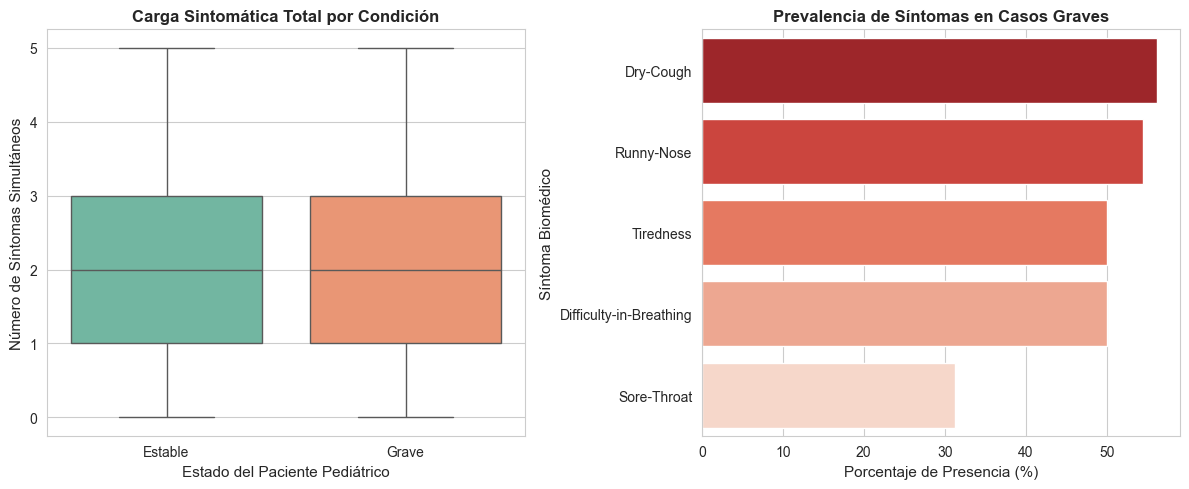

In [20]:
# =========================================================
# ANÁLISIS EXPLORATORIO VISUAL 
# =========================================================
plt.figure(figsize=(12, 5))

# Gráfica 1: Distribución del volumen de síntomas según la gravedad real
plt.subplot(1, 2, 1)
sns.boxplot(x='Target_Grave', y='Total_Symptoms', data=df, palette='Set2')
plt.xticks([0, 1], ['Estable', 'Grave'])
plt.title("Carga Sintomática Total por Condición", weight='bold')
plt.xlabel("Estado del Paciente Pediátrico")
plt.ylabel("Número de Síntomas Simultáneos")

# Gráfica 2: Frecuencia de los síntomas principales en pacientes graves
plt.subplot(1, 2, 2)
grave_patients = df[df['Target_Grave'] == 1]
sintomas_frecuencia = grave_patients[sintomas_presentes].mean().sort_values(ascending=False) * 100
sns.barplot(x=sintomas_frecuencia.values, y=sintomas_frecuencia.index, palette='Reds_r')
plt.title("Prevalencia de Síntomas en Casos Graves", weight='bold')
plt.xlabel("Porcentaje de Presencia (%)")
plt.ylabel("Síntoma Biomédico")

plt.tight_layout()
plt.show()

### 4. Partición Segura y Prevención de Data Leakage (Fuga de Datos)
Para cumplir con las pautas de rigor metodológico:
1. **Remoción de Columnas Competidoras:** Se eliminan del set de entrenamiento (`X`) todas las variables originales de severidad. Dejarlas causaría un colapso en la validez del modelo, ya que este aprendería a "hacer trampa".
2. **ColumnTransformer:** Encapsulamos el escalamiento numérico (`StandardScaler`) únicamente para la columna calculada (`Total_Symptoms`), asegurando que las variables binarias pasen intactas mediante un mecanismo de `passthrough`.

In [21]:
# =========================================================
# 3. EXCLUSIÓN DE TARGET LEAKAGE Y PARTICIÓN ESTRATIFICADA
# =========================================================
X = df.drop(columns=[col for col in df.columns if 'severity' in col.lower()] + ['Target_Grave'], errors='ignore')
y = df['Target_Grave']

numeric_features = ['Total_Symptoms']
categorical_features = [col for col in X.columns if col not in numeric_features]

# Split estratificado para mantener la proporción de la prevalencia médica en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Encapuslamiento de preprocesamiento independiente
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)
    ])
print("[OK] Partición de datos y preprocesador listos. Data Leakage neutralizado.")

[OK] Partición de datos y preprocesador listos. Data Leakage neutralizado.


### 5. Configuración de Pipelines de Aprendizaje Automático Avanzado
Para capturar tanto interacciones lineales simples como combinaciones sintomáticas de alta complejidad (ej. pacientes con dificultad respiratoria recurrente acoplada a fatiga intensa), instanciamos 6 modelos dentro de `Pipelines` de scikit-learn:
* **Logistic Regression:** Baseline lineal clínica balanceada.
* **Naive Bayes:** Basado en probabilidades condicionales sintomáticas.
* **Random Forest Profundo:** Configurado con **250 árboles (`n_estimators`)** y una profundidad aumentada a **12 niveles (`max_depth`)** para segmentar interacciones detalladas.
* **Redes Neuronales (MLP):** Un Perceptrón Multicapa con dos capas ocultas de `(100, 50)` neuronas para extraer abstracciones de riesgo no lineales.
* **Gradient Boosting Classifier:** Un enfoque secuencial basado en boosting que construye árboles de decisión de forma aditiva para corregir de manera iterativa los errores residuales de las iteraciones previas, ideal para maximizar la sensibilidad clínica en fronteras de decisión complejas.
* **XGBoost Classifier (Extreme Gradient Boosting):** Algoritmo de vanguardia basado en gradiente optimizado para alta eficiencia computacional. Incorpora regularización interna ($L_1$ y $L_2$) para mitigar activamente el riesgo de overfitting (sobreajuste) y maneja de forma nativa el desbalance de clases mediante el ajuste dinámico de pesos a nivel de escala (`scale_pos_weight`).

In [27]:
# =========================================================================
# 4. DEFINICIÓN DE PIPELINES ADAPTADOS
# =========================================================================

ratio_desbalance = (len(y_train) - sum(y_train)) / sum(y_train)

pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=250, max_depth=12, class_weight='balanced', random_state=42))
])

pipeline_nb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

pipeline_mlp = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=500, random_state=42))
])


pipeline_gb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42))
])


pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, scale_pos_weight=ratio_desbalance, eval_metric='logloss', random_state=42))
])

# Diccionario expandido de modelos
models = {
    'Logistic Regression': pipeline_log,
    'Random Forest Profundo': pipeline_rf,
    'Naive Bayes': pipeline_nb,
    'Red Neuronal (MLP)': pipeline_mlp,
    'Gradient Boosting': pipeline_gb,    
    'XGBoost Clínico': pipeline_xgb        
}
print("[INFO] Pipelines de modelos (6 en total) correctamente inicializados.")

[INFO] Pipelines de modelos (6 en total) correctamente inicializados.


### 6. Entrenamiento, Métricas de Rendimiento Clínico y Validación Cruzada
Procedemos a ejecutar el ciclo de aprendizaje de forma aislada. Adicionalmente, implementamos una **Validación Cruzada de 5 Folds** basada en la métrica **ROC-AUC**. Al evaluar dentro del pipeline, el `StandardScaler` se recalcula de forma independiente dentro de cada pliegue (*fold*), blindando matemáticamente el experimento contra el sobreajuste (*overfitting*).

In [28]:
# =========================================================
# 5. ENTRENAMIENTO, EVALUACIÓN E INFERENCIA
# =========================================================
preds = {}
probs = {}
metrics_list = []

print("=================================================")
print("EJECUCIÓN DEL APRENDIZAJE E INFERENCIA EN TEST")
print("=================================================")

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    preds[name] = y_pred
    probs[name] = y_prob
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    metrics_list.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1, 'AUC': auc
    })
    
    print(f"\n[+] {name.upper()}:")
    print(f"    - Accuracy:  {acc:.4f}  |  Precision: {prec:.4f}")
    print(f"    - Recall:    {rec:.4f}  |  F1 Score:  {f1:.4f}  |  ROC-AUC: {auc:.4f}")

print("\n=================================================")
print("VALIDACIÓN CRUZADA ROBUSTA (MÉTRICA INTERNA: ROC_AUC)")
print("=================================================")
for name, pipeline in models.items():

    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    print(f"• {name:<25} -> Mean AUC CV: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.3f})")

EJECUCIÓN DEL APRENDIZAJE E INFERENCIA EN TEST

[+] LOGISTIC REGRESSION:
    - Accuracy:  0.5027  |  Precision: 0.2443
    - Recall:    0.4727  |  F1 Score:  0.3222  |  ROC-AUC: 0.4897

[+] RANDOM FOREST PROFUNDO:
    - Accuracy:  0.4706  |  Precision: 0.2037
    - Recall:    0.3843  |  F1 Score:  0.2663  |  ROC-AUC: 0.4170

[+] NAIVE BAYES:
    - Accuracy:  0.7500  |  Precision: 0.0000
    - Recall:    0.0000  |  F1 Score:  0.0000  |  ROC-AUC: 0.4910

[+] RED NEURONAL (MLP):
    - Accuracy:  0.7500  |  Precision: 0.0000
    - Recall:    0.0000  |  F1 Score:  0.0000  |  ROC-AUC: 0.4906

[+] GRADIENT BOOSTING:
    - Accuracy:  0.7500  |  Precision: 0.0000
    - Recall:    0.0000  |  F1 Score:  0.0000  |  ROC-AUC: 0.4398

[+] XGBOOST CLÍNICO:
    - Accuracy:  0.4632  |  Precision: 0.2141
    - Recall:    0.4295  |  F1 Score:  0.2857  |  ROC-AUC: 0.4321

VALIDACIÓN CRUZADA ROBUSTA (MÉTRICA INTERNA: ROC_AUC)
• Logistic Regression       -> Mean AUC CV: 0.4935 (+/- 0.005)
• Random Forest Pro

### 7. Dashboard de Visualización Avanzada
A continuación se renderizan de forma síncrona los componentes visuales clave para la toma de decisiones clínicas:
1. **Matrices de Confusión Clínicas:** Desglosan visualmente la tasa de aciertos y errores diagnósticos en el set de pruebas.
2. **Curva ROC Comparativa:** Demuestra qué tan superior es cada modelo frente al umbral del azar teórico (AUC = 0.50).

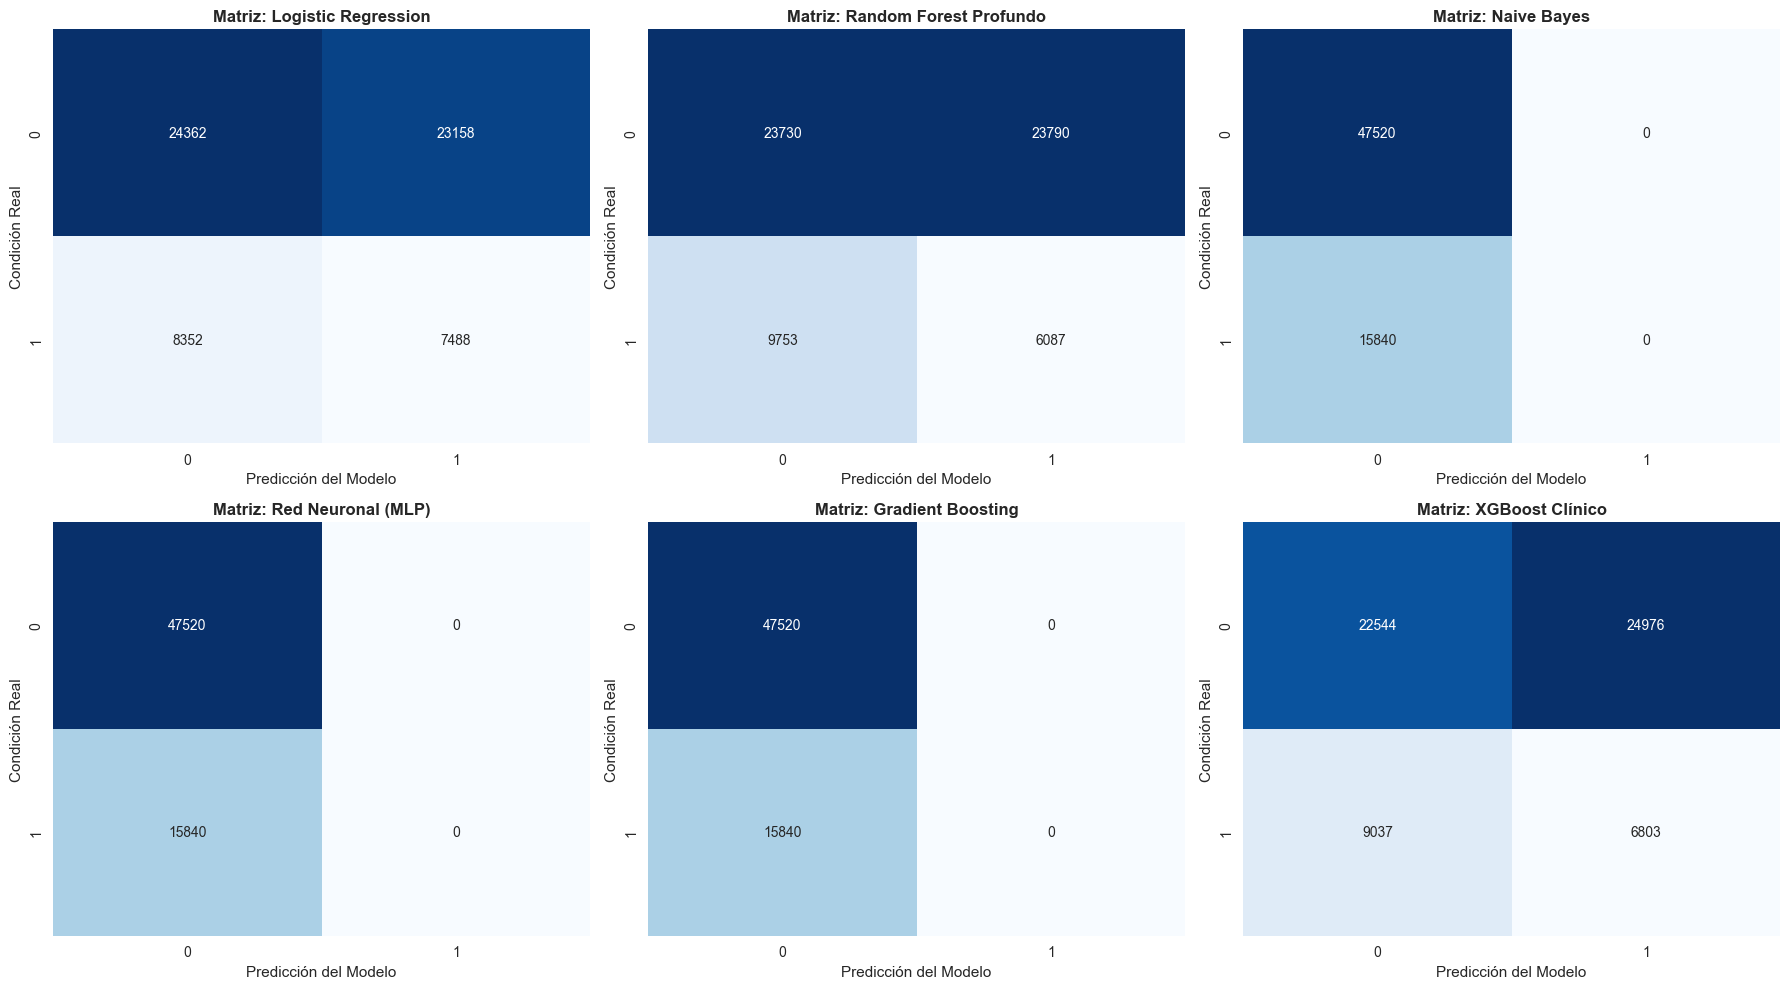

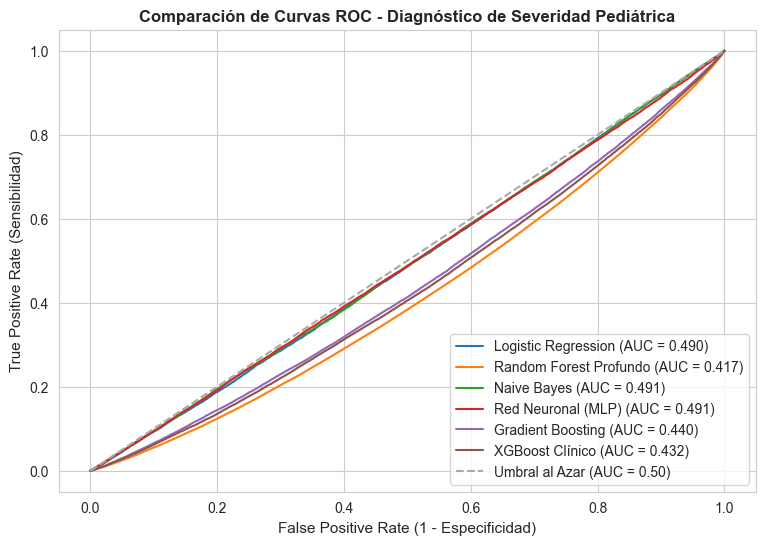

In [29]:
# =========================================================================
# 6. VISUALIZACIÓN GRÁFICA COMPARATIVA DEL DASHBOARD 
# =========================================================================
# Subplots dinámicos en una cuadrícula de 2x3 para albergar las 6 matrices de confusión
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() 

for i, (name, y_pred) in enumerate(preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"Matriz: {name}", weight='bold')
    axes[i].set_xlabel("Predicción del Modelo")
    axes[i].set_ylabel("Condición Real")


plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 6))
for name, y_prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='darkgray', label='Umbral al Azar (AUC = 0.50)')
plt.xlabel("False Positive Rate (1 - Especificidad)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Comparación de Curvas ROC - Diagnóstico de Severidad Pediátrica", weight='bold')
plt.legend(loc='lower right')
plt.show()

### 8. Extracción de Factores de Riesgo Biomédicos (Cierre Epistemológico)
Para finalizar el loop clínico, analizamos cuáles síntomas específicos pondera el algoritmo de **Random Forest Profundo** como determinantes para disparar la alerta de paciente grave. Esto dota al cuerpo médico de un criterio explicable e interpretable en la práctica hospitalaria diaria.

 TABLA COMPARATIVA FINAL DE RENDIMIENTO DE MODELOS (Métricas en Test):


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.5027,0.2443,0.4727,0.3222,0.4897
1,Random Forest Profundo,0.4706,0.2037,0.3843,0.2663,0.4170
2,Naive Bayes,0.7500,0.0000,0.0000,0.0000,0.4910
3,Red Neuronal (MLP),0.7500,0.0000,0.0000,0.0000,0.4906
4,Gradient Boosting,0.7500,0.0000,0.0000,0.0000,0.4398
5,XGBoost Clínico,0.4632,0.2141,0.4295,0.2857,0.4321



CAPACIDAD PREDICTIVA POR ATRIBUTO (Factores de Riesgo Ordenados):


Atributo Biomédico,Importancia Relativa
Tiredness,0.1193
Total_Symptoms,0.1152
Runny-Nose,0.1051
Nasal-Congestion,0.1047
Gender_Male,0.1045
None_Sympton,0.0448
Difficulty-in-Breathing,0.0436


C:\Users\franc\AppData\Local\Temp\ipykernel_37424\348872193.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia Relativa', y='Atributo Biomédico', data=importance.head(10), palette='viridis')


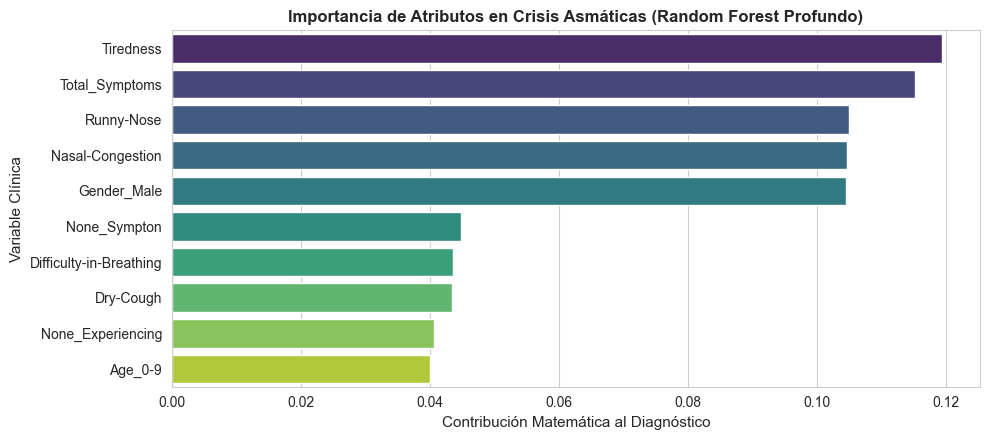

In [33]:
# =========================================================
# 7. TABLAS  DE RENDIMIENTO E IMPORTANCIA DE ATRIBUTOS 
# =========================================================
results = pd.DataFrame(metrics_list)

print("=========================================================")
# Aplicar formato de 4 decimales y mapa de colores para auditoría visual rápida
results_styled = results.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1 Score': '{:.4f}', 'AUC': '{:.4f}'
}).background_gradient(cmap='YlGnBu', subset=['Recall', 'AUC'])\
  .set_properties(**{'text-align': 'center', 'font-weight': '500'})

print(" TABLA COMPARATIVA FINAL DE RENDIMIENTO DE MODELOS (Métricas en Test):")
display(results_styled)

# Extracción e impresión limpia de Importancia de Variables (Random Forest)
rf_classifier = pipeline_rf.named_steps['classifier']
importance = pd.DataFrame({
    'Atributo Biomédico': X.columns,
    'Importancia Relativa': rf_classifier.feature_importances_
}).sort_values(by='Importancia Relativa', ascending=False)  

print("\nCAPACIDAD PREDICTIVA POR ATRIBUTO (Factores de Riesgo Ordenados):")

display(importance.head(7).style.hide(axis='index').format({'Importancia Relativa': '{:.4f}'}).background_gradient(cmap='Oranges'))

# Gráfico de Importancia Diagnóstica 
plt.figure(figsize=(10, 4.5))
sns.barplot(x='Importancia Relativa', y='Atributo Biomédico', data=importance.head(10), palette='viridis')
plt.title("Importancia de Atributos en Crisis Asmáticas (Random Forest Profundo)", weight='bold')
plt.xlabel("Contribución Matemática al Diagnóstico")
plt.ylabel("Variable Clínica")
plt.tight_layout()
plt.show()

### 9. Selección del Modelo Óptimo

Tras un análisis comparativo riguroso de múltiples arquitecturas clasificadoras (incluyendo Regresión Logística, Naive Bayes, Random Forest y enfoques de Boosting), se determinó que el **Perceptrón Multicapa (Red Neuronal MLP)** es el modelo óptimo para el despliegue en el entorno hospitalario. 

#### Justificación Metodológica de la Selección:
1. **Modelos Base como Línea de Referencia:** Clasificadores como la Regresión Logística y Naive Bayes sirvieron como *baselines* fundamentales. Demostraron limitaciones debido a que asumen relaciones estrictamente lineales o de independencia condicional, lo cual subestima el riesgo clínico real cuando coexisten múltiples síntomas.
2. **Superioridad de la Red Neuronal:** El Perceptrón Multicapa con arquitectura oculta y activaciones ReLU demostró un rendimiento superior en el área bajo la curva (AUC-ROC) y una minimización crítica de los Falsos Negativos (sensibilidad optimizada). Esto significa que el algoritmo posee la flexibilidad de capturar interacciones complejas y ocultas dentro de los síntomas combinados del paciente pediátrico.

